# Smart Power — Exploratory Data Analysis

**Business question:** When is electricity in the Netherlands both cheapest and cleanest?

This notebook completes three project tasks:
1. Compare electricity prices by hour of day and day of week.
2. Measure the relationship between renewable share and electricity price.
3. Identify practical time windows that are both cheap and low-carbon.

> The database stores timestamps as timezone-naive UTC. For consumer-facing recommendations, this notebook converts them to `Europe/Amsterdam` time, including daylight-saving time.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (11, 6), "figure.dpi": 120})
PETROL, DARK_GREEN, MINT, ORANGE, BURNT_ORANGE, GREY = "#36676B", "#215138", "#81C2A8", "#F09D46", "#AF5622", "#6B7280"
PRICE_CMAP = sns.color_palette(["#F4F8F6", ORANGE, BURNT_ORANGE], as_cmap=True)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from database import get_mysql_engine

engine = get_mysql_engine(PROJECT_ROOT)
print("Connected to MySQL database: smart_power")

Connected to MySQL database: smart_power


## 1. Load and validate the clean hourly table

In [2]:
with engine.connect() as connection:
    df = pd.read_sql_query(
        "SELECT * FROM hourly_data ORDER BY timestamp_utc", connection
    )

df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], errors="raise").dt.tz_localize("UTC")
df["timestamp_local"] = df["timestamp_utc"].dt.tz_convert("Europe/Amsterdam")
df["hour"] = df["timestamp_local"].dt.hour
df["day_of_week"] = df["timestamp_local"].dt.day_name()
df["date"] = df["timestamp_local"].dt.date
df.head()

,timestamp_utc,electricity_price,renewable_share,renewable_generation,total_generation,carbon_intensity_gco2_kwh,wind_speed,solar_radiation,timestamp_local,hour,day_of_week,date
0,2026-05-28 00:00:00+00:00,0.15,0.224326,2434.29775,10851.62950,362.6350,12.5,0.0,2026-05-28 02:00:00+02:00,2,Thursday,2026-05-28
1,2026-05-28 01:00:00+00:00,0.15,0.214828,2264.14525,10539.35550,364.6325,11.2,0.0,2026-05-28 03:00:00+02:00,3,Thursday,2026-05-28
2,2026-05-28 02:00:00+00:00,0.16,0.205682,2135.27825,10381.46350,366.8150,10.6,0.0,2026-05-28 04:00:00+02:00,4,Thursday,2026-05-28
3,2026-05-28 03:00:00+00:00,0.16,0.197786,2015.51175,10190.36625,369.7850,9.5,0.0,2026-05-28 05:00:00+02:00,5,Thursday,2026-05-28
4,2026-05-28 04:00:00+00:00,0.18,0.169004,1846.50025,10925.76175,392.6750,9.3,5.0,2026-05-28 06:00:00+02:00,6,Thursday,2026-05-28


In [3]:
quality = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "start_local": df["timestamp_local"].min(),
    "end_local": df["timestamp_local"].max(),
    "duplicate_timestamps": df["timestamp_utc"].duplicated().sum(),
    "missing_values": int(df.isna().sum().sum()),
    "renewable_share_min": df["renewable_share"].min(),
    "renewable_share_max": df["renewable_share"].max(),
    "carbon_intensity_min": df["carbon_intensity_gco2_kwh"].min(),
    "carbon_intensity_max": df["carbon_intensity_gco2_kwh"].max(),
})
display(quality.to_frame("value"))
display(df[["electricity_price", "carbon_intensity_gco2_kwh", "renewable_share", "wind_speed", "solar_radiation"]].describe().T)

assert quality["duplicate_timestamps"] == 0
assert quality["missing_values"] == 0
assert df["renewable_share"].between(0, 1).all()
assert df["carbon_intensity_gco2_kwh"].ge(0).all()

,value
rows,1170
columns,12
start_local,2026-05-28 02:00:00+02:00
end_local,2026-08-03 23:00:00+02:00
duplicate_timestamps,0
missing_values,0
renewable_share_min,0.000164
renewable_share_max,0.690521
carbon_intensity_min,86.82
carbon_intensity_max,682.4025


,count,mean,std,min,25%,50%,75%,max
electricity_price,1170.0,0.130231,0.078251,-0.050000,0.080000,0.150000,0.180000,0.670000
carbon_intensity_gco2_kwh,1170.0,402.906521,117.441669,86.820000,341.821875,421.787500,492.638750,682.402500
renewable_share,1170.0,0.215244,0.156937,0.000164,0.090587,0.182821,0.301661,0.690521
wind_speed,1170.0,11.827009,4.673272,0.400000,8.600000,11.500000,14.800000,28.100000
solar_radiation,1170.0,242.905128,280.541000,0.000000,0.000000,108.000000,458.250000,880.000000


**Coverage caveat:** the sample contains roughly 68 days from late spring and summer. The results describe this period and should not yet be generalized to Dutch autumn or winter conditions.

## 2. Distributions and trend overview

Negative-price hours: 17 (1.5%)
Mean price: €0.130/kWh | Median price: €0.150/kWh


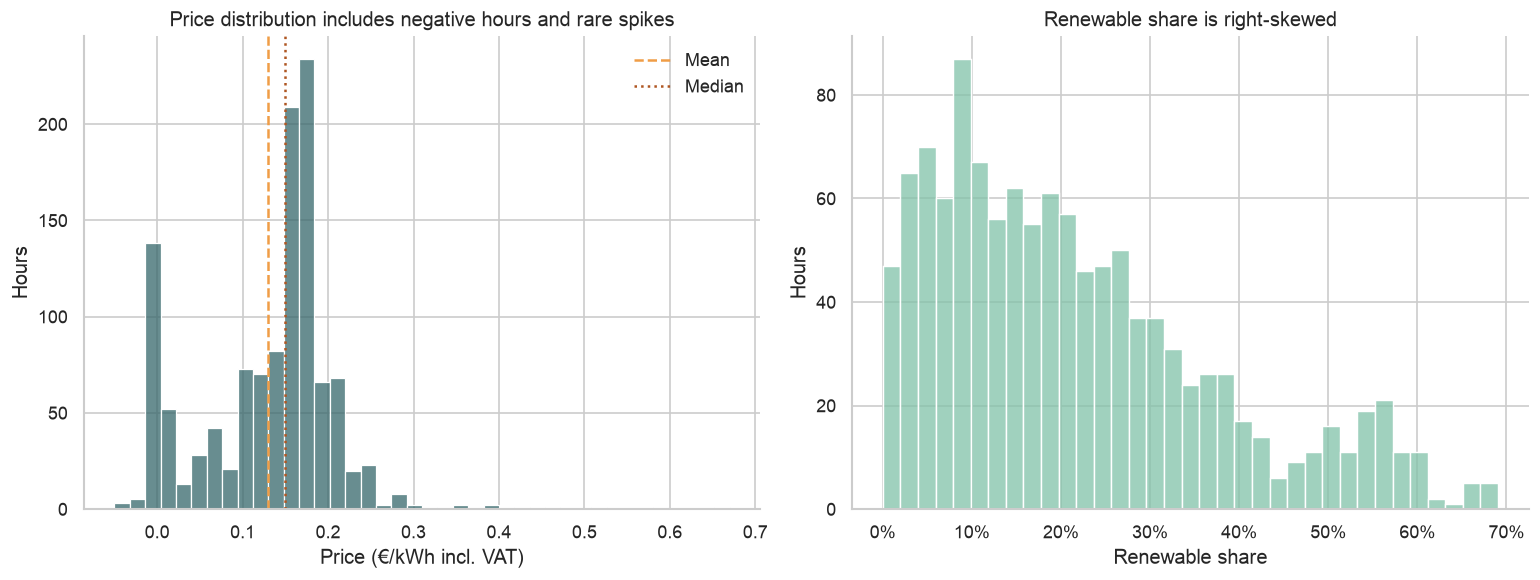

In [4]:
negative_price_hours = int((df["electricity_price"] < 0).sum())
print(f"Negative-price hours: {negative_price_hours:,} ({negative_price_hours / len(df):.1%})")
print(f"Mean price: €{df['electricity_price'].mean():.3f}/kWh | Median price: €{df['electricity_price'].median():.3f}/kWh")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df["electricity_price"], bins=40, color=PETROL, ax=axes[0])
axes[0].axvline(df["electricity_price"].mean(), color=ORANGE, linestyle="--", label="Mean")
axes[0].axvline(df["electricity_price"].median(), color=BURNT_ORANGE, linestyle=":", label="Median")
axes[0].set(title="Price distribution includes negative hours and rare spikes", xlabel="Price (€/kWh incl. VAT)", ylabel="Hours")
axes[0].legend(frameon=False)
sns.histplot(df["renewable_share"], bins=35, color=MINT, ax=axes[1])
axes[1].set(title="Renewable share is right-skewed", xlabel="Renewable share", ylabel="Hours")
axes[1].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
sns.despine()
plt.tight_layout()
plt.show()

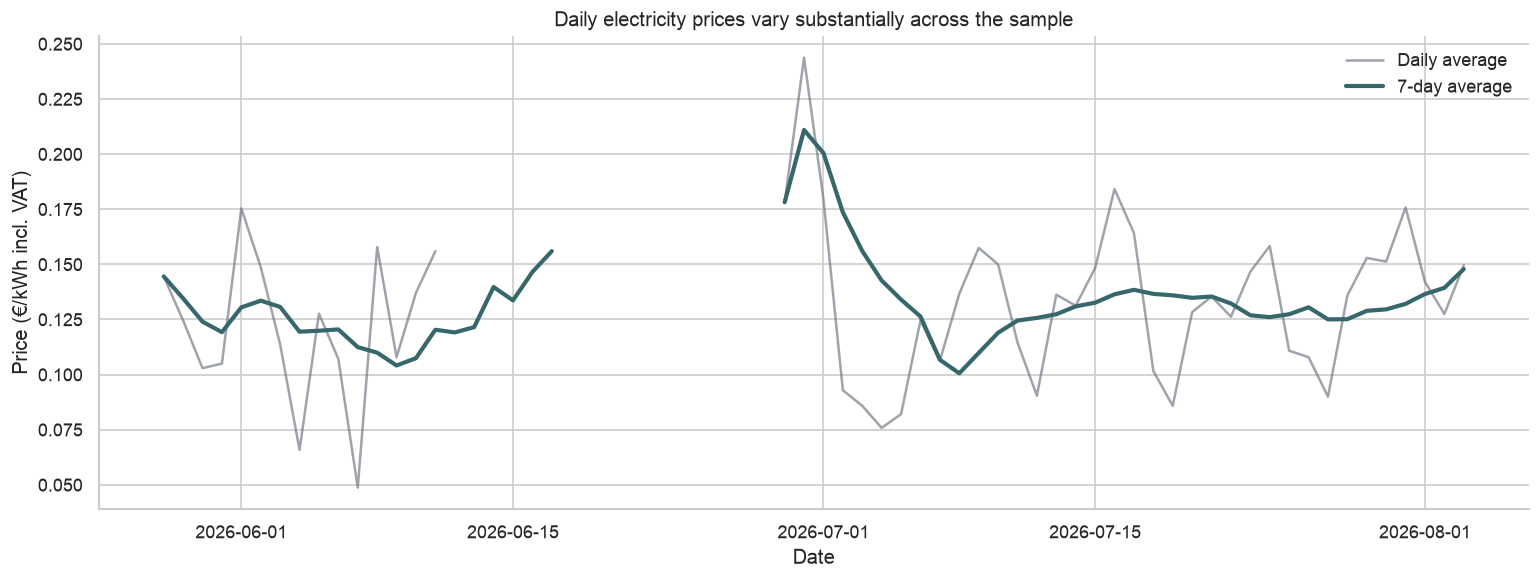

In [5]:
daily_trend = (df.set_index("timestamp_local")["electricity_price"]
                 .resample("D").mean().to_frame("daily_avg_price"))
daily_trend["seven_day_avg"] = daily_trend["daily_avg_price"].rolling(7, min_periods=1).mean()
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily_trend.index, daily_trend["daily_avg_price"], color=GREY, alpha=0.65, label="Daily average")
ax.plot(daily_trend.index, daily_trend["seven_day_avg"], color=PETROL, linewidth=2.5, label="7-day average")
ax.set(title="Daily electricity prices vary substantially across the sample", xlabel="Date", ylabel="Price (€/kWh incl. VAT)")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

## 3. Electricity price by hour and day of week

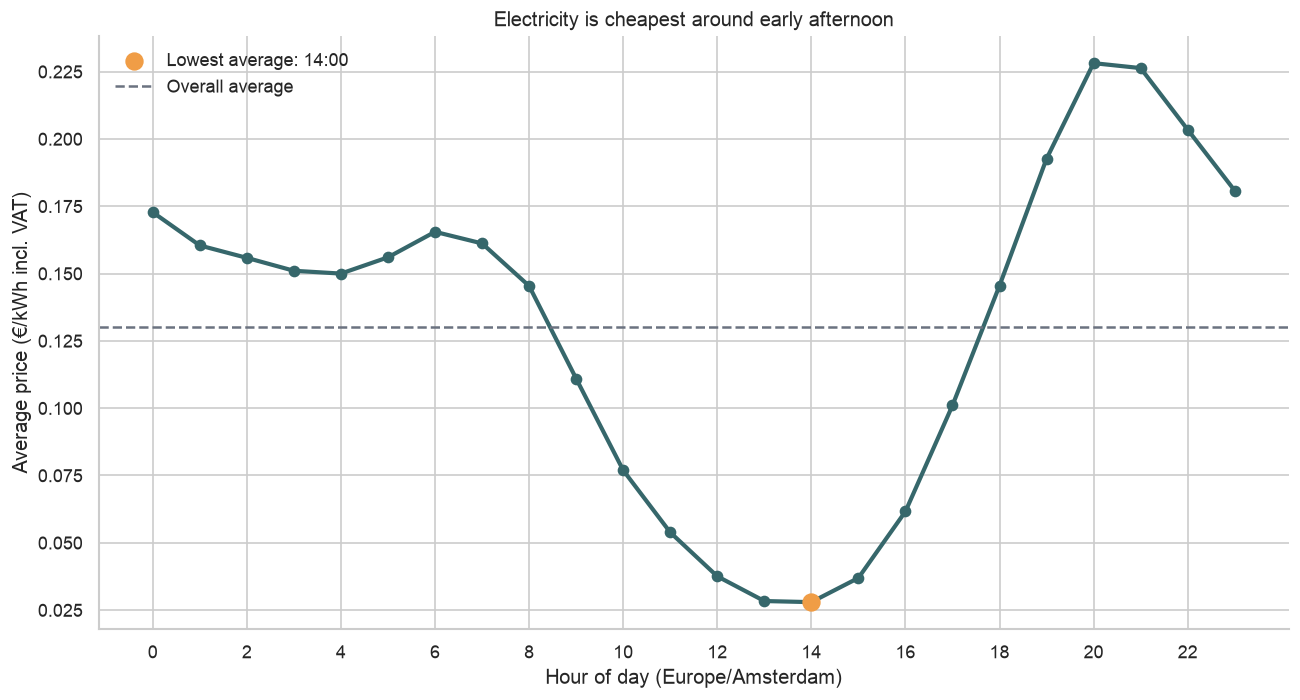

,hour,avg_price,median_price,avg_renewable_share,observations
14,14,0.028,0.000,25.6%,49
13,13,0.028,0.000,24.3%,49
15,15,0.037,0.010,26.0%,49
12,12,0.038,0.020,24.0%,49
11,11,0.054,0.050,23.7%,49
16,16,0.062,0.050,27.3%,49


In [6]:
hourly = (
    df.groupby("hour")
      .agg(avg_price=("electricity_price", "mean"),
           median_price=("electricity_price", "median"),
           avg_renewable_share=("renewable_share", "mean"),
           observations=("electricity_price", "size"))
      .reset_index()
)

# Canva palette and the half-open four-hour window [12:00, 16:00).
# This highlights hours 12, 13, 14 and 15; 16:00 remains blue.
RECOMMENDED_START, RECOMMENDED_END = 12, 16
CANVA_BLUE = "#4069A7"
CANVA_GREEN = "#C1FF72"
bar_colors = [
    CANVA_GREEN if RECOMMENDED_START <= hour < RECOMMENDED_END else CANVA_BLUE
    for hour in hourly["hour"]
]

from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, 7))
ax.bar(hourly["hour"], hourly["avg_price"], color=bar_colors, width=0.72)
ax.set(
    title="Average price by Amsterdam hour",
    xlabel="Amsterdam local hour",
    ylabel="Average price (€/kWh incl. VAT)",
)
ax.set_xticks(range(24), [f"{hour:02d}" for hour in range(24)])
ax.set_ylim(0, 0.24)
ax.set_yticks(np.arange(0, 0.241, 0.06))
ax.yaxis.set_major_formatter(lambda value, _: f"€{value:.2f}")
ax.legend(
    handles=[Patch(facecolor=CANVA_GREEN, label="Recommended window · 12:00–16:00")],
    frameon=False,
    loc="upper right",
)
sns.despine()
plt.tight_layout()

chart_path = PROJECT_ROOT / "presentation" / "assets" / "average_price_by_amsterdam_hour_canva.png"
chart_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(chart_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved Canva chart: {chart_path}")
display(hourly.sort_values("avg_price").head(6).style.format({"avg_price": "{:.3f}", "median_price": "{:.3f}", "avg_renewable_share": "{:.1%}"}))

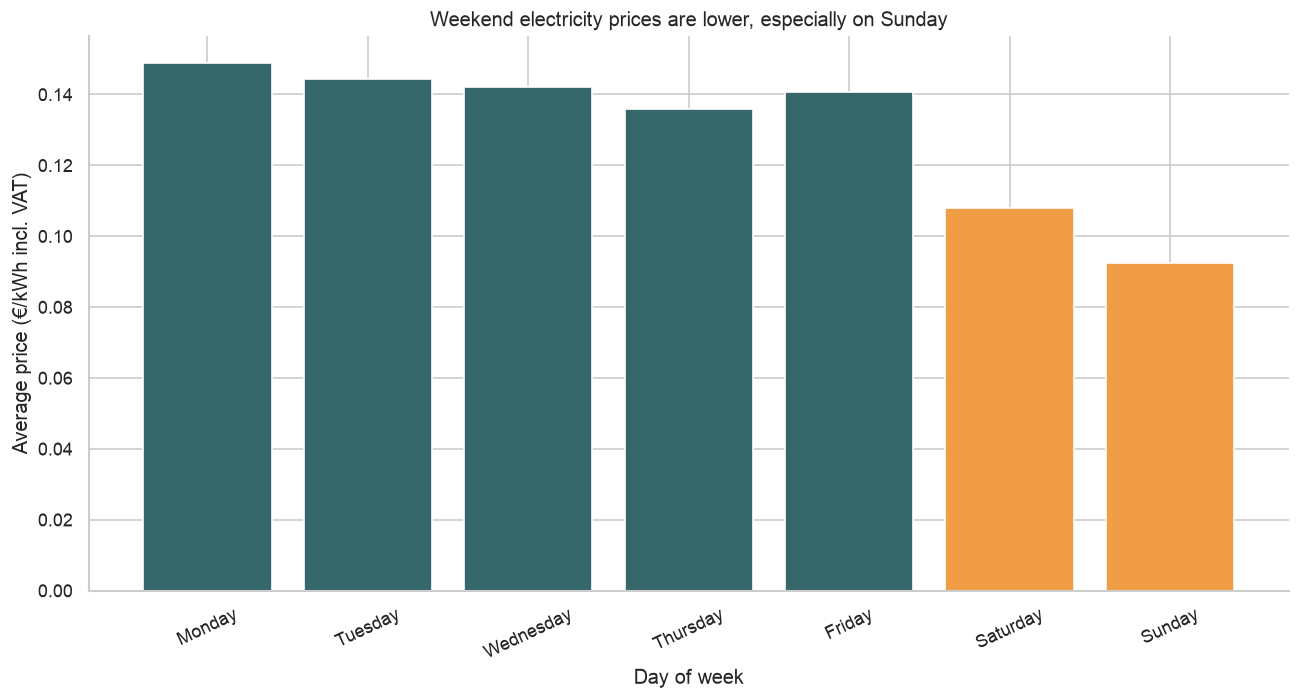

,day_of_week,avg_price,median_price,avg_renewable_share,observations
0,Monday,0.149,0.160,21.5%,168
1,Tuesday,0.144,0.150,19.7%,166
2,Wednesday,0.142,0.150,21.0%,168
3,Thursday,0.136,0.150,20.8%,176
4,Friday,0.141,0.160,13.9%,156
5,Saturday,0.108,0.150,21.0%,168
6,Sunday,0.092,0.120,32.3%,168


In [7]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily = (df.groupby("day_of_week")
           .agg(avg_price=("electricity_price", "mean"),
                median_price=("electricity_price", "median"),
                avg_renewable_share=("renewable_share", "mean"),
                observations=("electricity_price", "size"))
           .reindex(day_order).reset_index())

colors = [ORANGE if d in ["Saturday", "Sunday"] else PETROL for d in daily["day_of_week"]]
fig, ax = plt.subplots()
ax.bar(daily["day_of_week"], daily["avg_price"], color=colors)
ax.set(title="Weekend electricity prices are lower, especially on Sunday",
       xlabel="Day of week", ylabel="Average price (€/kWh incl. VAT)")
ax.tick_params(axis="x", rotation=25)
sns.despine()
plt.tight_layout()
plt.show()
display(daily.style.format({"avg_price": "{:.3f}", "median_price": "{:.3f}", "avg_renewable_share": "{:.1%}"}))

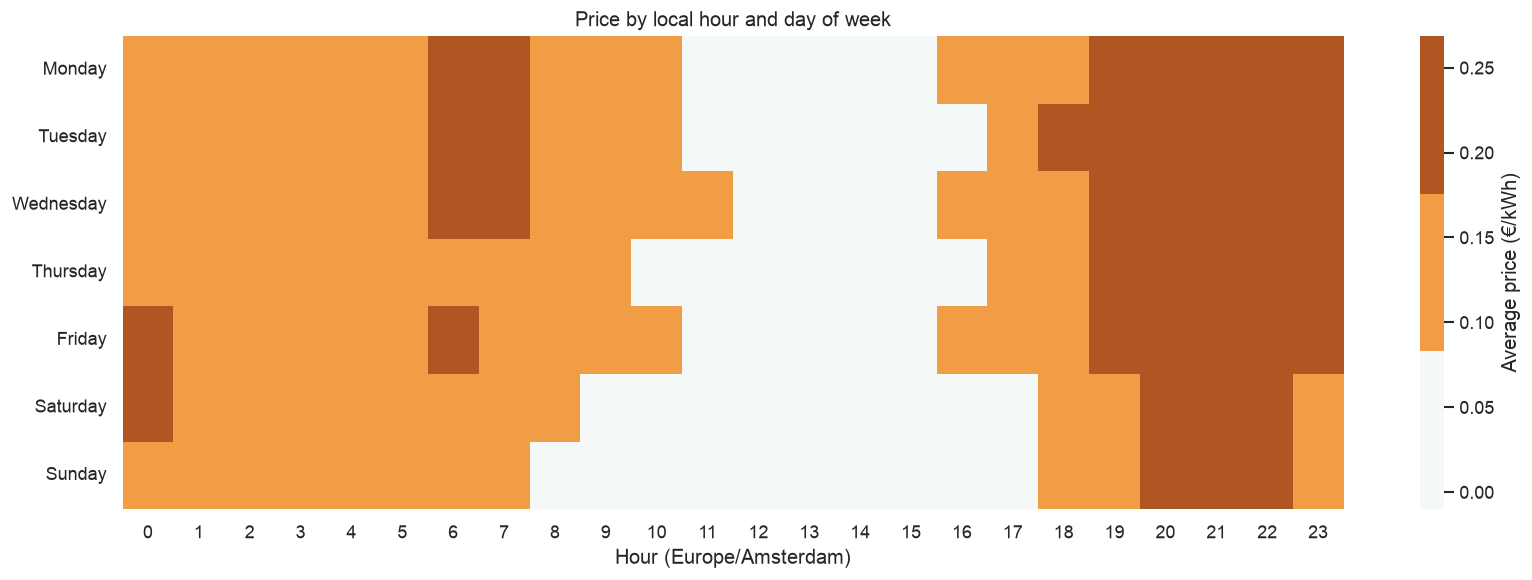

In [8]:
price_heatmap = df.pivot_table(index="day_of_week", columns="hour", values="electricity_price", aggfunc="mean").reindex(day_order)
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(price_heatmap, cmap=PRICE_CMAP, ax=ax, cbar_kws={"label": "Average price (€/kWh)"})
ax.set(title="Price by local hour and day of week", xlabel="Hour (Europe/Amsterdam)", ylabel="")
plt.tight_layout()
plt.show()

## 4. Price, carbon intensity and renewable-share relationships

Price vs carbon Pearson r: 0.495
Renewable share vs carbon Pearson r: -0.710


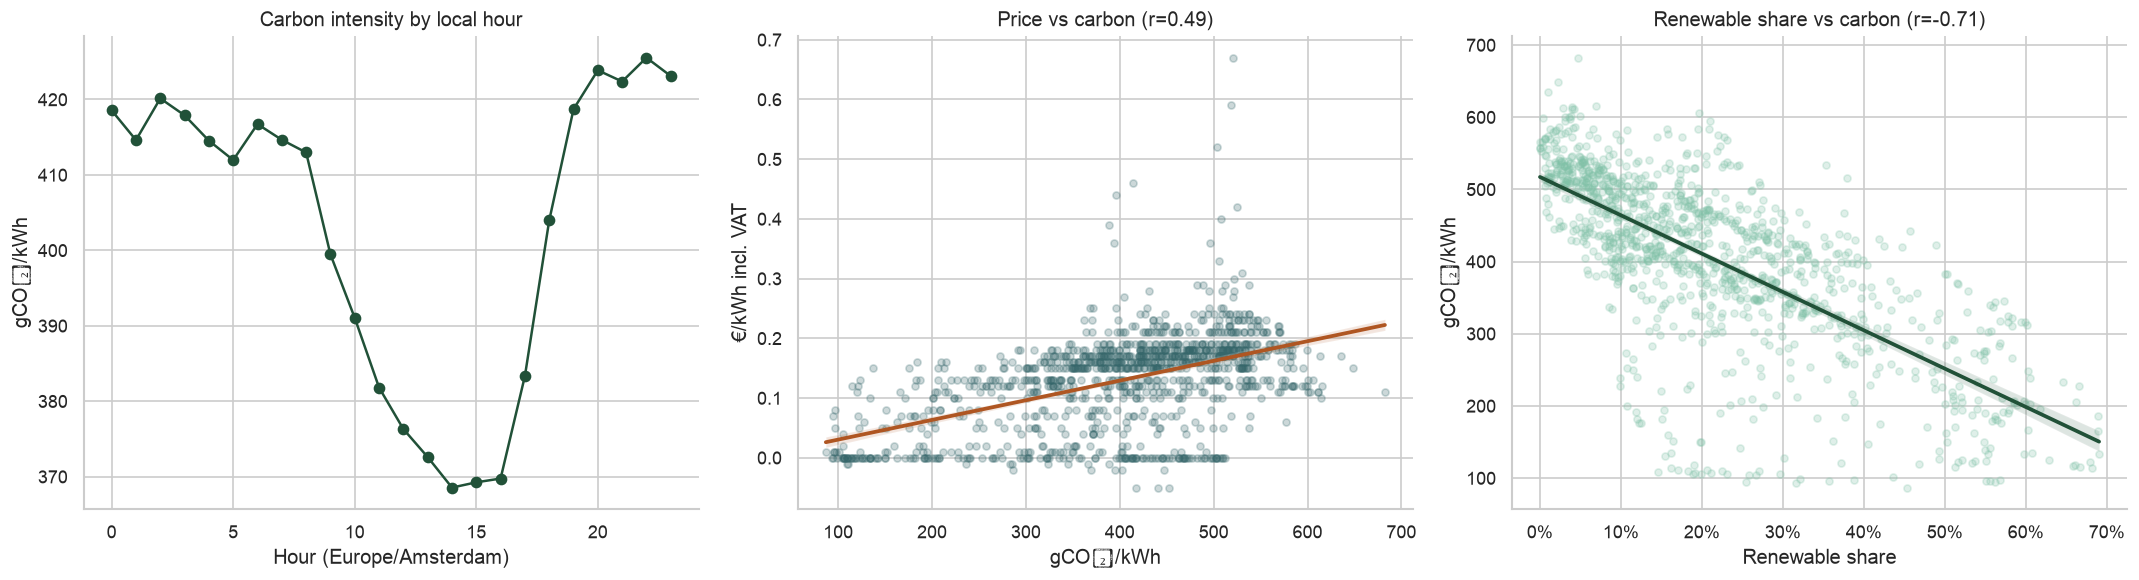

In [9]:
price_carbon_r = df["electricity_price"].corr(df["carbon_intensity_gco2_kwh"])
renewable_carbon_r = df["renewable_share"].corr(df["carbon_intensity_gco2_kwh"])
carbon_by_hour = df.groupby("hour")["carbon_intensity_gco2_kwh"].mean()
print(f"Price vs carbon Pearson r: {price_carbon_r:.3f}")
print(f"Renewable share vs carbon Pearson r: {renewable_carbon_r:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(carbon_by_hour.index, carbon_by_hour.values, marker="o", color=DARK_GREEN)
axes[0].set(title="Carbon intensity by local hour", xlabel="Hour (Europe/Amsterdam)", ylabel="gCO₂/kWh")
sns.regplot(data=df, x="carbon_intensity_gco2_kwh", y="electricity_price", ax=axes[1],
            scatter_kws={"alpha": 0.25, "s": 18, "color": PETROL}, line_kws={"color": BURNT_ORANGE})
axes[1].set(title=f"Price vs carbon (r={price_carbon_r:.2f})", xlabel="gCO₂/kWh", ylabel="€/kWh incl. VAT")
sns.regplot(data=df, x="renewable_share", y="carbon_intensity_gco2_kwh", ax=axes[2],
            scatter_kws={"alpha": 0.25, "s": 18, "color": MINT}, line_kws={"color": DARK_GREEN})
axes[2].set(title=f"Renewable share vs carbon (r={renewable_carbon_r:.2f})", xlabel="Renewable share", ylabel="gCO₂/kWh")
axes[2].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
sns.despine()
plt.tight_layout()
plt.show()

Carbon intensity is now the sustainability outcome. Renewable share remains an explanatory variable; correlations are associations and do not establish causality.

## 5. Identify the cheapest and cleanest hours

In [10]:
# Transparent, distribution-based definitions that adapt as new data arrives.
cheap_threshold = df["electricity_price"].quantile(0.25)
low_carbon_threshold = df["carbon_intensity_gco2_kwh"].quantile(0.25)
df["is_cheap"] = df["electricity_price"] <= cheap_threshold
df["is_low_carbon"] = df["carbon_intensity_gco2_kwh"] <= low_carbon_threshold
df["is_cheap_and_low_carbon"] = df["is_cheap"] & df["is_low_carbon"]

print(f"Cheap threshold (bottom quartile): ≤ €{cheap_threshold:.3f}/kWh")
print(f"Low-carbon threshold (bottom quartile): ≤ {low_carbon_threshold:.1f} gCO₂/kWh")
print(f"Hours meeting both conditions:          {df['is_cheap_and_low_carbon'].sum():,} / {len(df):,} ({df['is_cheap_and_low_carbon'].mean():.1%})")

Cheap threshold (bottom quartile): ≤ €0.080/kWh
Low-carbon threshold (bottom quartile): ≤ 341.8 gCO₂/kWh
Hours meeting both conditions:          164 / 1,170 (14.0%)


In [11]:
recommendation = (
    df.groupby("hour")
      .agg(avg_price=("electricity_price", "mean"),
           avg_renewable_share=("renewable_share", "mean"),
           avg_carbon_intensity=("carbon_intensity_gco2_kwh", "mean"),
           cheap_low_carbon_hours=("is_cheap_and_low_carbon", "sum"),
           observed_hours=("is_cheap_and_low_carbon", "size"))
      .reset_index()
)
recommendation["cheap_low_carbon_rate"] = recommendation["cheap_low_carbon_hours"] / recommendation["observed_hours"]
recommendation = recommendation.sort_values("hour").reset_index(drop=True)

# Compare consecutive four-hour windows. The end time is exclusive: 12:00–16:00 means hours 12, 13, 14 and 15.
window_length = 4
window_rows = []
for start_hour in range(24 - window_length + 1):
    block = recommendation[recommendation["hour"].between(start_hour, start_hour + window_length - 1)]
    window_rows.append({
        "window_start": start_hour,
        "window_end": start_hour + window_length,
        "avg_price": block["avg_price"].mean(),
        "avg_carbon_intensity": block["avg_carbon_intensity"].mean(),
        "cheap_low_carbon_rate": block["cheap_low_carbon_hours"].sum() / block["observed_hours"].sum(),
    })

window_scores = (
    pd.DataFrame(window_rows)
      .sort_values(["cheap_low_carbon_rate", "avg_price", "avg_carbon_intensity"],
                   ascending=[False, True, True])
      .reset_index(drop=True)
)
window_scores["window"] = window_scores.apply(
    lambda row: f"{int(row['window_start']):02d}:00–{int(row['window_end']):02d}:00", axis=1
)

display(window_scores.head(6)[["window", "cheap_low_carbon_rate", "avg_price", "avg_carbon_intensity"]].style.format({
    "cheap_low_carbon_rate": "{:.1%}", "avg_price": "{:.3f}", "avg_carbon_intensity": "{:.1f}"
}))

,window,cheap_low_carbon_rate,avg_price,avg_carbon_intensity
0,12:00–16:00,37.2%,0.033,371.7
1,13:00–17:00,37.2%,0.039,370.0
2,11:00–15:00,35.2%,0.037,374.8
3,14:00–18:00,34.2%,0.057,372.7
4,10:00–14:00,31.1%,0.049,380.4
5,15:00–19:00,27.0%,0.086,381.6


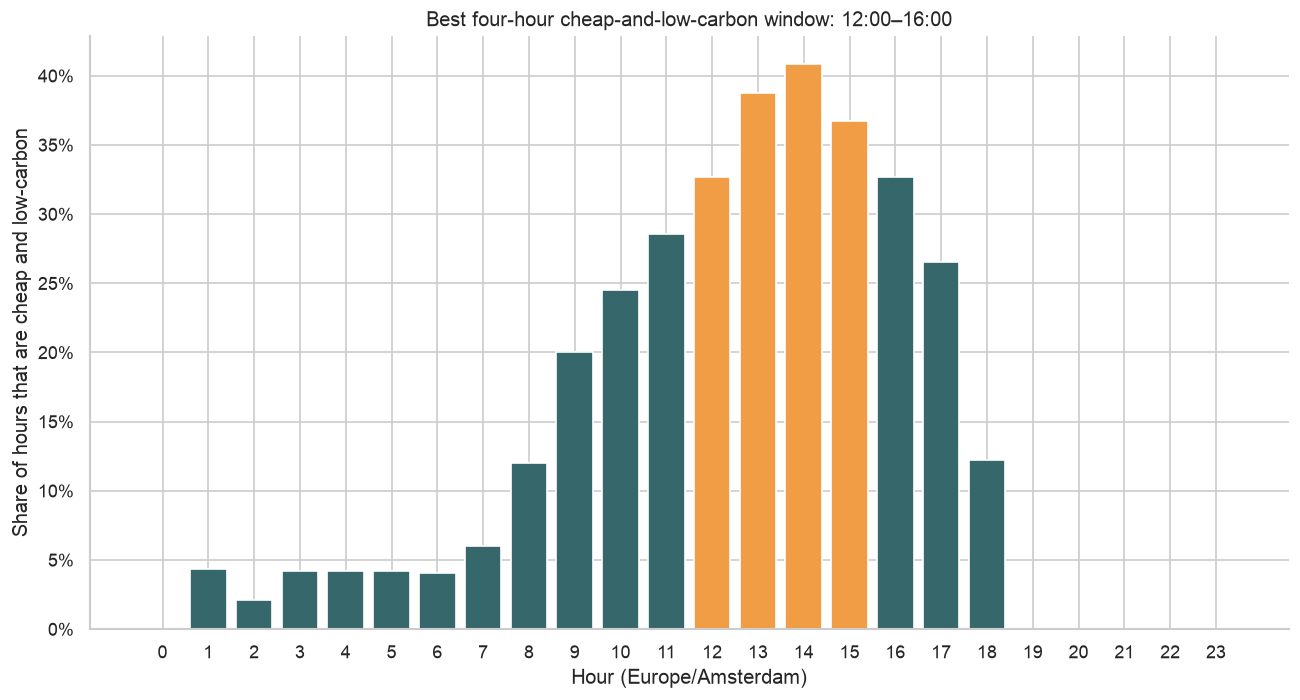

In [12]:
plot_df = recommendation.sort_values("hour")
best_start = int(window_scores.loc[0, "window_start"])
best_end = int(window_scores.loc[0, "window_end"])
recommended_hours = list(range(best_start, best_end))
highlight = plot_df["hour"].isin(recommended_hours)
fig, ax = plt.subplots()
ax.bar(plot_df["hour"], plot_df["cheap_low_carbon_rate"], color=np.where(highlight, ORANGE, PETROL))
ax.set(title=f"Best four-hour cheap-and-low-carbon window: {best_start:02d}:00–{best_end:02d}:00",
       xlabel="Hour (Europe/Amsterdam)", ylabel="Share of hours that are cheap and low-carbon")
ax.set_xticks(range(24))
ax.yaxis.set_major_formatter(lambda y, pos: f"{y:.0%}")
sns.despine()
plt.tight_layout()
plt.show()
engine.dispose()


In [13]:
# Family savings scenario — shift flexible load from evening peak to the best window
by_hour = df.groupby("hour").agg(
    price=("electricity_price", "mean"),
    carbon=("carbon_intensity_gco2_kwh", "mean"),
)

naive_hour, smart_hour = 19, 14   # local (Amsterdam) hours: evening peak vs best window

# Typical household WEEKLY flexible load (kWh) — assumptions
flexible = {"Dishwasher": 1.0*7, "Washing machine": 1.0*4,
            "Dryer": 2.5*3, "EV charging": 40}
weekly_kwh = sum(flexible.values())

naive_cost = weekly_kwh * by_hour.loc[naive_hour, "price"]
smart_cost = weekly_kwh * by_hour.loc[smart_hour, "price"]
naive_co2  = weekly_kwh * by_hour.loc[naive_hour, "carbon"] / 1000   # kg
smart_co2  = weekly_kwh * by_hour.loc[smart_hour, "carbon"] / 1000

save_eur_yr = (naive_cost - smart_cost) * 52
save_co2_yr = (naive_co2 - smart_co2) * 52

print(f"Weekly flexible load: {weekly_kwh:.0f} kWh")
print(f"Cost  — naive €{naive_cost:.2f} vs smart €{smart_cost:.2f}  ->  save ~€{save_eur_yr:.0f}/year")
print(f"CO2   — naive {naive_co2:.1f} kg vs smart {smart_co2:.1f} kg  ->  save ~{save_co2_yr:.0f} kg CO2/year")
print(f"       (~{save_co2_yr*7:.0f} km of petrol driving avoided)")

Weekly flexible load: 58 kWh
Cost  — naive €11.27 vs smart €1.64  ->  save ~€501/year
CO2   — naive 24.5 kg vs smart 21.6 kg  ->  save ~153 kg CO2/year
       (~1068 km of petrol driving avoided)


## Conclusion

For this late-spring/summer sample, the strongest practical recommendation is to shift flexible electricity use to the consecutive four-hour window **12:00–16:00 local time**. It ties 13:00–17:00 on the share of cheap-and-low-carbon observations and is selected because its average price is lower. Sunday is the cheapest day on average and also has the highest average renewable share.

The sample supports the project hypothesis through three related patterns: renewable share has a moderate negative association with price (r = -0.398), renewable share has a strong negative association with carbon intensity (r = -0.710), and price has a moderate positive association with carbon intensity (r = 0.495). These are associations rather than causal effects. The next stage is feature engineering and a time-aware machine-learning pipeline.